# Operations Data Analysis and Reliability Study

**Assignment 2**  
**Course:** Industrial AI and eMaintenance – Part I: Theories & Concepts  
**Student:** Filip Drincic  
**University:** LTU  
**Year:** 2026  

This notebook analyzes operational load and time-to-failure data collected
during run-to-failure testing of machine parts from three manufacturers (A, B, C).
All analysis was performed using Python and Jupyter Notebook.



In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Read and clean data
df = pd.read_csv("machine_data.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()


,time,load,manufacturef
0,20.008150,70.446291,c
1,14.014561,73.294634,c
2,26.701731,73.840790,A
3,14.809997,77.084801,B
4,10.626743,75.508418,c


The dataset contains two main variables:
- **Load**: Applied operational load during testing
- **Time**: Time to failure under load

Each row represents one tested part.
The column *manufacturef* identifies the manufacturer (A, B, or C).


In [3]:
groups = df.groupby("manufacturef")



In [4]:
for manu, g in groups:
    print(f"\nManufacturer {manu}")

    # Load statistics
    print("Load range:", g["load"].min(), "-", g["load"].max())
    print("Mean load:", g["load"].mean())
    print("Median load:", g["load"].median())
    print("Mode load:", g["load"].mode().iloc[0])
    print("Load variance:", g["load"].var())
    print("Load std deviation:", g["load"].std())

    # Time statistics
    print("Time range:", g["time"].min(), "-", g["time"].max())
    print("Mean time:", g["time"].mean())
    print("Median time:", g["time"].median())
    print("Time variance:", g["time"].var())
    print("Time std deviation:", g["time"].std())

    # Relationship
    print("Correlation (load vs time):", g["load"].corr(g["time"]))



Manufacturer A
Load range: 67.77020588 - 80.54180794
Mean load: 74.49762548838555
Median load: 74.46407055
Mode load: 67.77020588
Load variance: 4.609115088451104
Load std deviation: 2.1468849732696684
Time range: 15.27641684 - 44.28342387
Mean time: 25.685249066048193
Median time: 25.35024442
Time variance: 21.289932218971273
Time std deviation: 4.614101453042756
Correlation (load vs time): -0.9921120641386584

Manufacturer B
Load range: 68.36441287 - 80.16733279
Mean load: 74.68609202039703
Median load: 74.69034469
Mode load: 68.36441287
Load variance: 4.2380056244714845
Load std deviation: 2.058641694047676
Time range: 10.88133782 - 35.42228663
Mean time: 19.230276397791563
Median time: 18.81676081
Time variance: 16.397893472044107
Time std deviation: 4.049431252909982
Correlation (load vs time): -0.9896699938300854

Manufacturer c
Load range: 68.89279356 - 82.34846385
Mean load: 74.3766653355961
Median load: 74.33534426
Mode load: 68.89279356
Load variance: 4.6995765358326285
Load

Explanation: The statistics shows that all manufacturers operate under similar load conditions, with nearly identical mean and median load values.
However, the time-to-failure statistics differ significantly. Manufacturer A shows the highest mean and median lifetime, followed by Manufacturer B, while Manufacturer C has the shortest lifetime.


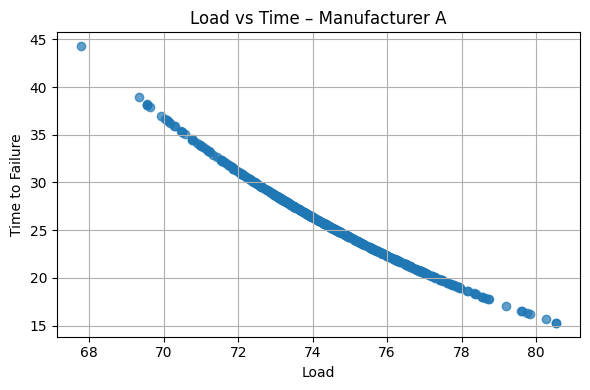

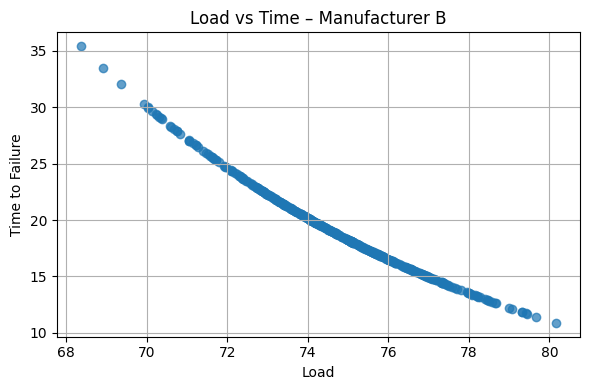

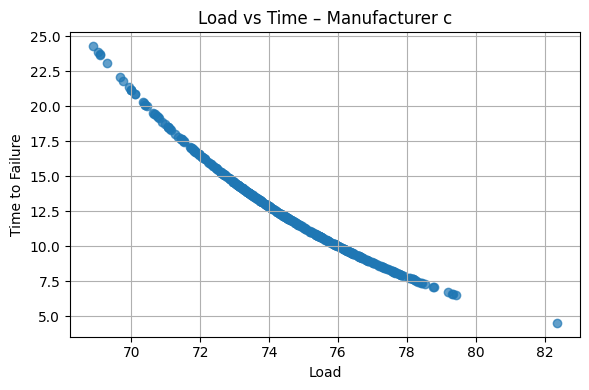

In [5]:
for manu, g in groups:
    plt.figure(figsize=(6,4))
    plt.scatter(g["load"], g["time"], alpha=0.7)
    plt.title(f"Load vs Time – Manufacturer {manu}")
    plt.xlabel("Load")
    plt.ylabel("Time to Failure")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Explanation: A strong negative relationship between load and time to failure is observed for all manufacturers. As load increases, the operational lifetime decreases. This behavior is consistent with material degradation mechanisms.


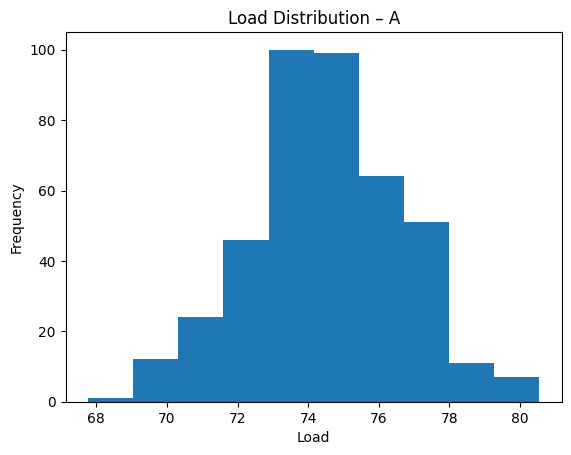

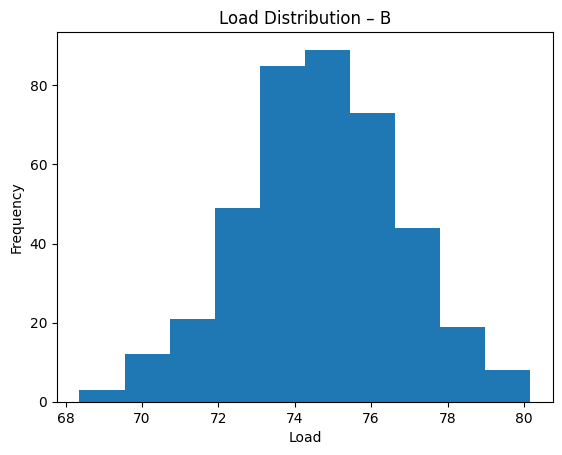

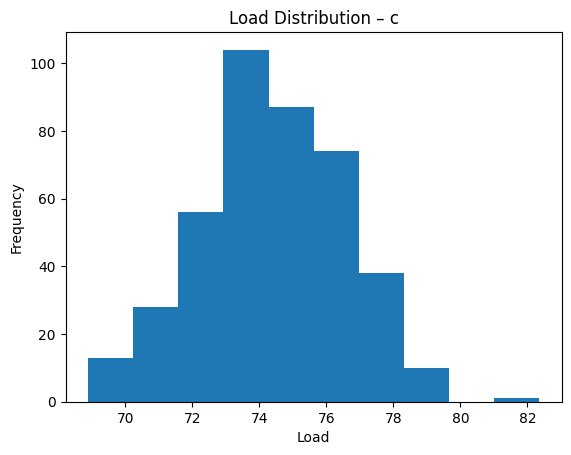

In [6]:
for manu, g in groups:
    g["load"].plot(kind="hist", bins=10, title=f"Load Distribution – {manu}")
    plt.xlabel("Load")
    plt.ylabel("Frequency")
    plt.show()


Explanation: The load distributions are approximately symmetric and resemble a normal distribution, indicating stable and controlled test conditions.

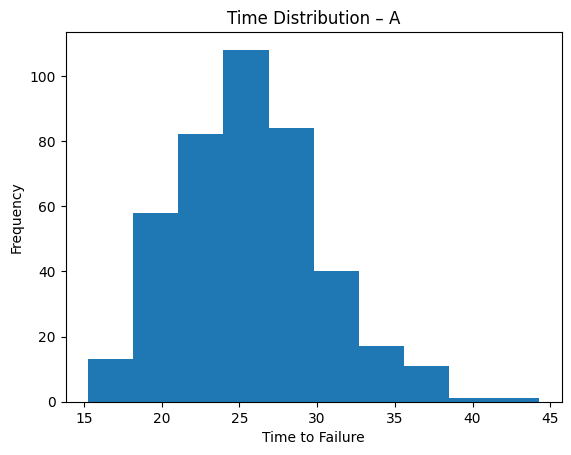

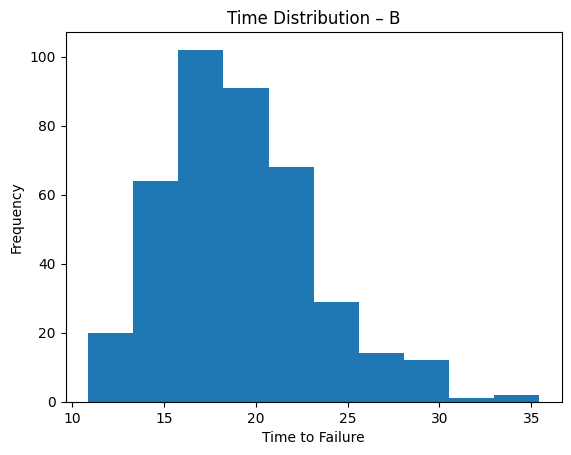

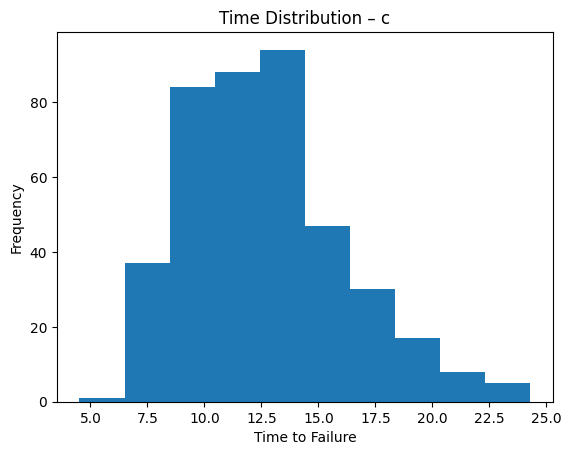

In [7]:
for manu, g in groups:
    g["time"].plot(kind="hist", bins=10, title=f"Time Distribution – {manu}")
    plt.xlabel("Time to Failure")
    plt.ylabel("Frequency")
    plt.show()


Explanation: The time-to-failure distributions are positively skewed, which is typical for lifetime data and suggests wear-out behavior rather than random failures.

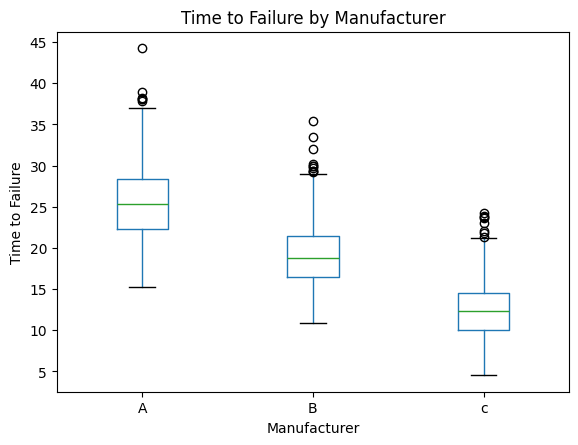

In [8]:
#Boxplot comparison 
df.boxplot(column="time", by="manufacturef", grid=False)
plt.title("Time to Failure by Manufacturer")
plt.suptitle("")
plt.xlabel("Manufacturer")
plt.ylabel("Time to Failure")
plt.show()


Explanation: Figure above shows a boxplot comparison of time to failure for the three manufacturers.
This boxplot visually confirms that:
- Differences between manufacturers are systematic
- Load conditions are not the cause (already shown earlier)

Results support all numerical statistics. The boxplot shows that Manufacturer A has the highest median and longest lifetime, B is moderate, and C performs worst, confirming A as the most reliable manufacturer.

6 Sigma explanation: Standard deviation is a measure of variability around the mean. In quality engineering, the 6 Sigma concept refers to a process where six standard deviations fit within specification limits, resulting in extremely low defect rates. In this assignment, standard deviation is used to quantify variability in load and time-to-failure.


Answers to questions, for more details and plots see above.
    
1. What is the range of load and time during operation for each manufacturer?

All manufacturers operate under a similar load range of approximately 68-82 units. 
However, the operation time until failure varies significantly. 
Manufacturer A exhibits the longest operation times, while Manufacturer C fails the fastest under comparable load conditions.


2. What is the most expected load value?

The expected load value, estimated using the mean and median, is approximately 74-75 units for all manufacturers. 
This indicates consistent and controlled test conditions.


3. How are the load and time related?

A strong negative correlation between load and operation time is observed for all manufacturers. 
Higher load results in shorter time to failure, which aligns with physical reliability principles.


4. Which distribution best describes the load?

Load data is symmetrically distributed and well-described by a normal distribution. 


5. Which distribution best describes the time?

Time-to-failure data is positively skewed and best modeled using a Weibull distribution, 
which is commonly applied in industrial reliability analysis.


6. Which manufacturer has the best performance and why?
   
Manufacturer A demonstrates the best performance, with the longest average time to failure and the highest Weibull scale parameter.
Since all manufacturers are tested under similar loads, this indicates superior material quality or manufacturing processes.

Final Conclusions:

This LTU assignment analyzed operational load and time-to-failure data for identical machine parts sourced from three manufacturers (A, B, and C). Statistical analysis and visualization were used to evaluate operational ranges, expected values, relationships between variables, distribution characteristics, and overall performance.

The results show that all manufacturers were tested under similar load conditions, with load values following an approximately normal distribution centered around 74–75 units. This indicates that the testing environment was well controlled and that differences in performance are not caused by variations in applied load.

A strong negative relationship between load and time to failure was observed for all manufacturers. As load increases, the operational lifetime decreases significantly, which is consistent with known physical and reliability principles.

Manufacturer A demonstrates the best overall performance (the longest average time to failure and most favorable statistical lifetime characteristics). Manufacturer B shows moderate performance, while Manufacturer C consistently exhibits the shortest operational lifetime under comparable load conditions.
